### Практическое задание №3. Классификация мест залежей нефти и газа
## Вдовина Д.Н.

In [51]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [52]:
# загружаем данные train датасет
df = pd.read_csv('/Users/darasaporeva/Desktop/Python/data/train_oil.csv')
df.info() # выводим информацию о данных train датасет

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 20 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      309 non-null    object 
 1   Reservoir unit                  309 non-null    object 
 2   Country                         282 non-null    object 
 3   Region                          271 non-null    object 
 4   Basin name                      271 non-null    object 
 5   Tectonic regime                 309 non-null    object 
 6   Latitude                        282 non-null    float64
 7   Longitude                       279 non-null    float64
 8   Operator company                309 non-null    object 
 9   Onshore/Offshore                309 non-null    object 
 10  Hydrocarbon type                309 non-null    object 
 11  Reservoir status                309 non-null    object 
 12  Structural setting              309 

In [53]:
# загружаем данные test датасет
df_test = pd.read_csv('/Users/darasaporeva/Desktop/Python/data/oil_test.csv')
df_test.info() # выводим информацию о данных test датасет

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 19 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Field name                      133 non-null    object 
 1   Reservoir unit                  133 non-null    object 
 2   Country                         120 non-null    object 
 3   Region                          117 non-null    object 
 4   Basin name                      125 non-null    object 
 5   Tectonic regime                 133 non-null    object 
 6   Latitude                        120 non-null    float64
 7   Longitude                       117 non-null    float64
 8   Operator company                133 non-null    object 
 9   Hydrocarbon type                133 non-null    object 
 10  Reservoir status                133 non-null    object 
 11  Structural setting              133 non-null    object 
 12  Depth                           133 

In [54]:
# загружаем данные
display(df.head())
display(df_test.head())

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ZHIRNOV,MELEKESKIAN,RUSSIA,FORMER SOVIET UNION,VOLGA-URAL,COMPRESSION/EVAPORITE,51.0000,44.8042,NIZHNEVOLZHSKNET,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,LAGOA PARDA,LAGOA PARDA (URUCUTUCA),BRAZIL,LATIN AMERICA,ESPIRITO SANTO,EXTENSION,-19.6017,-39.8332,PETROBRAS,ONSHORE,OIL,NEARLY DEPLETED,PASSIVE MARGIN,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION/EVAPORITE,26.0800,49.8100,SAUDI ARAMCO,ONSHORE,OIL,REJUVENATING,FORELAND,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,MURCHISON,BRENT,UK /NORWAY,EUROPE,NORTH SEA NORTHERN,EXTENSION,61.3833,1.7500,CNR,OFFSHORE,OIL,NEARLY DEPLETED,RIFT,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0
4,WEST PEMBINA,NISKU (PEMBINA L POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,53.2287,-115.8008,NUMEROUS,ONSHORE,OIL,UNKNOWN,FORELAND,9306,DEVONIAN,DOLOMITE,233.0,167.0,11.8,1407.0


,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ABU GHARADIG,BAHARIYA,EGYPT,AFRICA,ABU GHARADIG,EXTENSION,29.7422,28.4925,GUPCO,GAS-CONDENSATE,MATURE PRODUCTION,RIFT,10282,CRETACEOUS,SANDSTONE,745.0,144.0,10.0,8.0
1,ABU MADI-EL QARA,ABU MADI (LEVEL III),EGYPT,AFRICA,NILE DELTA,STRIKE-SLIP/TRANSTENSION/SHALE/EVAPORITE/BASEM...,31.4382,31.3616,IEOC,GAS,DECLINING PRODUCTION,WRENCH/DELTA,10499,NEOGENE,SANDSTONE,509.0,410.0,20.0,300.0
2,ALIBEKMOLA,KT I,KAZAKHSTAN,FORMER SOVIET UNION,CASPIAN NORTH,COMPRESSION/EVAPORITE,48.4740,57.6667,KAZAKHOIL AKTOBE,OIL,DEVELOPING,SUB-SALT/FORELAND,6000,CARBONIFEROUS,LIMESTONE,300.0,105.0,10.0,20.0
3,ALWYN NORTH,BRENT (BRENT EAST),UK,EUROPE,NORTH SEA NORTHERN,INVERSION/COMPRESSION/EXTENSION,60.7833,1.7333,TOTAL,OIL,NEARLY DEPLETED,RIFT,9790,JURASSIC,SANDSTONE,886.0,344.0,17.0,500.0
4,ANKLESHWAR,ANKLESHWAR (HAZAD-ARDOL),INDIA,FAR EAST,CAMBAY,STRIKE-SLIP/TRANSPRESSION/BASEMENT-I,21.6000,72.9167,ONGC,OIL,MATURE PRODUCTION,WRENCH/RIFT,2950,PALEOGENE,SANDSTONE,670.0,0.0,21.0,250.0


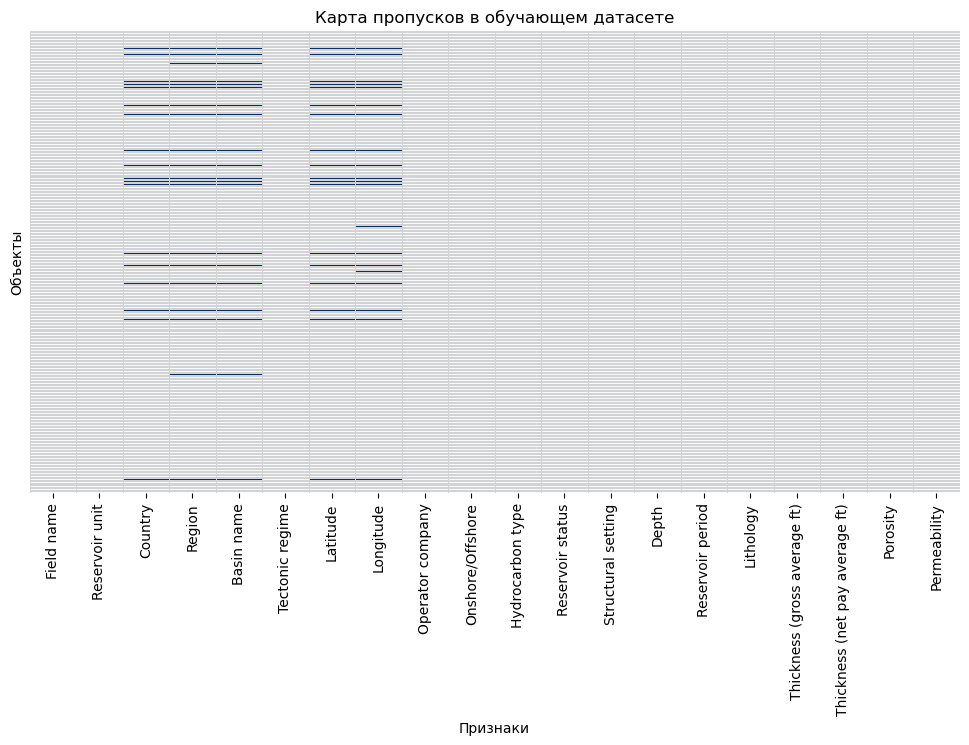

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
# визуализируем пропуски в данных с помощью тепловой карты
plt.figure(figsize=(12, 6))
sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='Blues',
    linewidths=0.4,
    linecolor='lightgray'
)
plt.title('Карта пропусков в обучающем датасете')
plt.xlabel('Признаки')
plt.ylabel('Объекты')
plt.show()

По тепловой карте можно сделать вывод, что часть пропусков встречается в одних и тех же строках, то есть отсутствующие значения частично связаны между собой. Значит, что пропуски сосредоточены в ограниченном числе признаков и не затрагивают датасет целиком.

In [56]:
# посмотрим, какие столбцы содержат пропущенные значения в train датасет
df_nan = df.loc[:, df.isnull().any()]
# посмотрим процент пропущенных значений в каждом столбце с пропущенными данными в train датасет
df_nan.isnull().sum() / len(df_nan) * 100

Country        8.737864
Region        12.297735
Basin name    12.297735
Latitude       8.737864
Longitude      9.708738
dtype: float64

In [57]:
# посмотрим, какие столбцы содержат пропущенные значения в test датасет
df_nan_test = df_test.loc[:, df_test.isnull().any()]
# посмотрим процент пропущенных значений в каждом столбце с пропущенными данными в test датасет
df_nan_test.isnull().sum() / len(df_nan_test) * 100

Country        9.774436
Region        12.030075
Basin name     6.015038
Latitude       9.774436
Longitude     12.030075
dtype: float64

Анализ показал, что пропуски в тестовом датасете сосредоточены в тех же признаках, что и в обучающем. Их доля также находится на сопоставимом уровне. Это подтверждает, что для train и test можно применять одну и ту же стратегию обработки пропусков.

In [58]:
# посмотрим, количество столбцов в train и test датасетах
print('Train shape:', df.shape)
print('Test shape:', df_test.shape)

Train shape: (309, 20)
Test shape: (133, 19)


In [59]:
# сравним названия столбцов в train и test датасетах подвердим их различия
train_cols = set(df.columns)
test_cols = set(df_test.columns)

print('Есть в train, но нет в test:', train_cols - test_cols)
print('Есть в test, но нет в train:', test_cols - train_cols)

Есть в train, но нет в test: {'Onshore/Offshore'}
Есть в test, но нет в train: set()


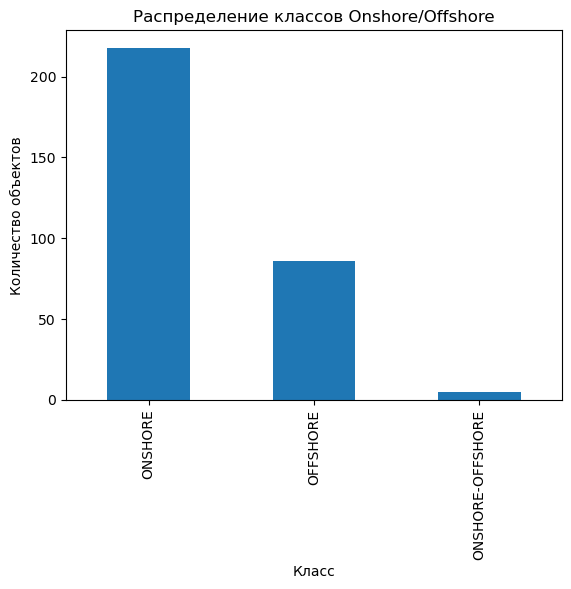

Количество объектов по классам:
Onshore/Offshore
ONSHORE             218
OFFSHORE             86
ONSHORE-OFFSHORE      5
Name: count, dtype: int64

Процент объектов по классам:
Onshore/Offshore
ONSHORE             70.55
OFFSHORE            27.83
ONSHORE-OFFSHORE     1.62
Name: proportion, dtype: float64


In [60]:
# посмотри на распределение Onshore/Offshore через value_counts() на графике
df['Onshore/Offshore'].value_counts().plot(kind='bar')
# добавить подписи к осям и заголовок
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.title('Распределение классов Onshore/Offshore')
# показать график
plt.show()
# посмотри на распределение Onshore/Offshore через value_counts() и процентное соотношение классов
print('Количество объектов по классам:') 
print(df['Onshore/Offshore'].value_counts()) 
print('\nПроцент объектов по классам:') 
print((df['Onshore/Offshore'].value_counts(normalize=True) * 100).round(2)) 

**Вывод:**
1. Целевая переменная Onshore/Offshore содержит 3 класса, следовательно задача относится к многоклассовой классификации.

2. Наиболее часто встречается класс ONSHORE (70.55%), затем OFFSHORE (27.83%)

3. Классы неравномерны, при этом ONSHORE преобладают, а Класс ONSHORE-OFFSHORE представлен всего 5 объектами (1.62%)

4. Модель может быть смещена в сторону класса ONSHORE, так как он доминирует в данных. Если не предпринять меры, алгоритм может чаще предсказывать ONSHORE, игнорируя другие классы.

5. Этот дисбаланс необходимо учитывать при дальнейшем обучении моделей и оценке их качества.

In [61]:
# проверим на наличие дубликатов 
print('Количество полных дубликатов в train:', df.duplicated().sum())
print('Количество полных дубликатов в test:', df_test.duplicated().sum())

Количество полных дубликатов в train: 0
Количество полных дубликатов в test: 0


In [62]:
# определим целевую переменную
target_col = 'Onshore/Offshore'

# проверим, что целевая переменная есть в train датасете
assert target_col in df.columns, f"В df нет колонки {target_col}. Есть: {df.columns.tolist()}"

# определим категориальные и числовые признаки в обучающем датасете (для train)
feature_cat_cols = df.drop(columns=[target_col]).select_dtypes(include="object").columns.tolist()
feature_num_cols = df.drop(columns=[target_col]).select_dtypes(exclude="object").columns.tolist()

print("Категориальные признаки:")
print(feature_cat_cols)
print("\nЧисловые признаки:")
print(feature_num_cols)

Категориальные признаки:
['Field name', 'Reservoir unit', 'Country', 'Region', 'Basin name', 'Tectonic regime', 'Operator company', 'Hydrocarbon type', 'Reservoir status', 'Structural setting', 'Reservoir period', 'Lithology']

Числовые признаки:
['Latitude', 'Longitude', 'Depth', 'Thickness (gross average ft)', 'Thickness (net pay average ft)', 'Porosity', 'Permeability']


In [63]:
# посмотрим на уникальные значения в целевой переменной. 
y_map = {"OFFSHORE": 0, "ONSHORE": 1, "ONSHORE-OFFSHORE": 2} # отображаем классы в числовые значения
df[target_col] = df[target_col].map(y_map) # заменяем строковые классы на числовые

# проверим, что в целевой переменной нет пропущенных значений после замены классов на числовые значения
if df[target_col].isna().any():
    raise ValueError("Есть неизвестные значения таргета")

# проверим распределение классов в целевой переменной после замены классов на числовые значения
df[target_col] = df[target_col].astype(int)
display(df[target_col].value_counts().sort_index())

Onshore/Offshore
0     86
1    218
2      5
Name: count, dtype: int64

In [64]:
import geopandas as gpd
import geodatasets

# Задаем целевую переменную и создаем маску для редкого класса
target_col = "Onshore/Offshore"
mask = df[target_col].eq(2)

# Выбираем объекты с редким классом и их географические координаты
rare = df.loc[mask, ["Latitude", "Longitude"]].copy()

# Загружаем геопространственные данные о суше и создаем GeoDataFrame для редких объектов
land = gpd.read_file(geodatasets.get_path("naturalearth.land")).geometry.union_all()
gdf = gpd.GeoDataFrame(
    rare,
    geometry=gpd.points_from_xy(rare["Longitude"], rare["Latitude"]),
    crs="EPSG:4326",
)
# Исправляем редкие классы в целевой переменной, используя геопространственные данные
df.loc[mask, target_col] = np.where(gdf.within(land), 1, 0)

display(df.loc[mask, ["Latitude", "Longitude", target_col]])

,Latitude,Longitude,Onshore/Offshore
64,50.6672,-2.0278,1
92,NaN,NaN,0
134,39.5800,53.1300,0
185,44.3367,-1.0959,1
220,33.6998,-118.0335,1


 В обучающем датасете обнаружено 5 объектов с редким классом ONSHORE–OFFSHORE (ранее присвоен класс 2). Чтобы избежать шума мы уточнили их принадлежность к ONSHORE (1) или OFFSHORE (0) по географическим координатам: если точка попадает на сушу — ONSHORE, иначе — OFFSHORE. В результате редкий класс был устранён: 3 объекта отнесены к ONSHORE, 2 — к OFFSHORE, и таргет стал бинарным (0/1)

## Промежуточный вывод для дальнейшей обработки данных
В датасете также обнаружено 5 признаков с пропусками: Country, Region, Basin name, Latitude, Longitude.

Так как выборка небольшая и в целевой переменной наблюдается дисбаланс классов, удаление строк с пропусками может привести к потере полезной информации.

Генерацию синтетических значений решено не использовать, поскольку такой подход может исказить структуру данных и ухудшить воспроизводимость результата.

В качестве стратегии обработки пропусков выбрано заполнение категориальных признаков значением "Unknown", а числовых — медианными значениями.

In [65]:
# создадим копии датасетов, чтобы исходные данные остались без изменений
train = df.copy()
test = df_test.copy()

# списки столбцов с пропусками
cat_missing_cols = ['Country', 'Region', 'Basin name']
num_missing_cols = ['Latitude', 'Longitude']

# заполняем категориальные пропуски
train[cat_missing_cols] = train[cat_missing_cols].fillna('Unknown')
test[cat_missing_cols] = test[cat_missing_cols].fillna('Unknown')

# заполняем числовые пропуски медианами, посчитанными по train
train_medians = train[num_missing_cols].median()
# заполняем пропуски в числовых столбцах в train и test датасетах
train[num_missing_cols] = train[num_missing_cols].fillna(train_medians)
test[num_missing_cols] = test[num_missing_cols].fillna(train_medians)

# проверим, что пропуски заполнены и в train, и в test датасете
print('Общее число пропусков в train после заполнения:', train.isnull().sum().sum())
print('Общее число пропусков в test после заполнения:', test.isnull().sum().sum())


Общее число пропусков в train после заполнения: 0
Общее число пропусков в test после заполнения: 0


In [66]:
# приводим таргет к 2 классам (0/1) по координатам
mask = train[target_col].eq(2)
if mask.any():
    land = gpd.read_file(geodatasets.get_path("naturalearth.land")).geometry.union_all()
    pts = gpd.GeoSeries(
        gpd.points_from_xy(train.loc[mask, "Longitude"], train.loc[mask, "Latitude"]),
        crs="EPSG:4326",
    )
    train.loc[mask, target_col] = np.where(pts.within(land), 1, 0)

In [67]:
# проверим распределение классов в целевой переменной после устранения редкого класса
X = train.drop(columns=[target_col])
y = train[target_col].astype(int)

print("X:", X.shape, "y:", y.shape)

X: (309, 19) y: (309,)


In [68]:
# Анализ составных категорий (значения с символом "/") в категориальных признаках (с другими разделительными знаками не обнаружено, но проверку из кода удалила)
cat_data = X.select_dtypes(include="object")
# посчитаем количество строк с символом "/" в каждом категориальном признаке
multi_counts = cat_data.apply(
    lambda s: s.dropna().astype(str).str.contains("/", regex=False).sum()
)
# отфильтруем признаки, в которых есть строки с символом "/"
multi_counts = multi_counts[multi_counts > 0].sort_values(ascending=False)
multi_share = (multi_counts / len(X) * 100).round(2)

multi_summary = pd.DataFrame(
    {
        "Количество строк с '/'": multi_counts,
        "Доля от всех объектов, %": multi_share,
    }
)

display(multi_summary)

,Количество строк с '/',"Доля от всех объектов, %"
Tectonic regime,209,67.64
Structural setting,112,36.25
Operator company,25,8.09
Basin name,4,1.29
Reservoir unit,3,0.97
Country,3,0.97


Дополнительно была выполнена проверка категориальных признаков на наличие составных значений с символом /, в которых одна запись может содержать несколько характеристик. С остальными разделительными признаками объектов в датасете не обнаружено. 

Это важно для выбора способа кодирования: если кодировать всю строку целиком, можно потерять информацию о её отдельных компонентах. 

Чаще всего составные значения встречаются в признаках Tectonic regime и Structural setting, поэтому именно их будtv рассматривать отдельно при кодировании. 

Остальные признаки содержат символ / значительно реже, поэтому их можно рассматривать как обычные категориальные признаки и обрабатывать стандартным способом.

Сначала не кодируем, не удаляем, не разбиваем автоматически. Проверим, из каких частей они состоят (если внутри этих признаков повторяются одни и те же компоненты, тогда есть смысл разбивать строку по / и делать из компонентов отдельные бинарные признаки)


In [69]:
# посмотрим компоненты в составных признака (для Tectonic regime в train датасете)
tectonic_examples = (
    X.loc[X['Tectonic regime'].str.contains('/', regex=False), ['Tectonic regime']]
    .drop_duplicates()
    .head(15)
    .reset_index(drop=True)
)

tectonic_examples

,Tectonic regime
0,COMPRESSION/EVAPORITE
1,INVERSION/COMPRESSION/EXTENSION/EVAPORITE
2,GRAVITY/EXTENSION/SHALE/SYNSEDIMENTATION
3,COMPRESSION/EROSION
4,EXTENSION/EROSION
5,EXTENSION/EVAPORITE
6,COMPRESSION/SHALE
7,GRAVITY/EVAPORITE/EXTENSION
8,STRIKE-SLIP/INVERSION/COMPRESSION/EXTENSION
9,INVERSION/COMPRESSION/EXTENSION


Значения подтверждают, что признак Tectonic regime содержит комбинации нескольких компонентов, разделённых символом /.  Следовательно целесообразно разбиение признака на отдельные бинарные признаки.

In [70]:
# посмотрим компоненты в составных признака (для Structural setting в train датасете)
structural_examples = (
    X.loc[X['Structural setting'].str.contains('/', regex=False), ['Structural setting']]
    .drop_duplicates()
    .head(15)
    .reset_index(drop=True)
)

structural_examples

,Structural setting
0,INVERSION/RIFT
1,DELTA/PASSIVE MARGIN
2,THRUST/SUB-THRUST/FORELAND
3,SALT/RIFT
4,WRENCH/INVERSION/BACKARC
5,SUB-SALT/FORELAND
6,WRENCH/RIFT
7,SALT/FORELAND
8,SALT/INVERSION/RIFT
9,INVERSION/BACKARC


Значения признака Structural setting также содержат комбинации нескольких компонентов, разделённых символом /.  Следовательно целесообразно разбиение признака на отдельные бинарные признаки.

In [71]:
# разложим составные признаки на отдельные бинарные признаки (для Tectonic regime и Structural setting в train датасете)
tectonic_dummies = X['Tectonic regime'].str.get_dummies(sep='/').add_prefix('tectonic_')
structural_dummies = X['Structural setting'].str.get_dummies(sep='/').add_prefix('structural_')

# удалим исходные составные признаки и добавим новые бинарные признаки
X = X.drop(columns=['Tectonic regime', 'Structural setting'])
X = pd.concat([X, tectonic_dummies, structural_dummies], axis=1)

# посмотрим результат
print('Размер X после преобразования:', X.shape)
X.head()

Размер X после преобразования: (309, 46)


,Field name,Reservoir unit,Country,Region,Basin name,Latitude,Longitude,Operator company,Hydrocarbon type,Reservoir status,...,structural_FORELAND,structural_INTRACRATONIC,structural_INVERSION,structural_PASSIVE MARGIN,structural_RIFT,structural_SALT,structural_SUB-SALT,structural_SUB-THRUST,structural_THRUST,structural_WRENCH
0,ZHIRNOV,MELEKESKIAN,RUSSIA,FORMER SOVIET UNION,VOLGA-URAL,51.0000,44.8042,NIZHNEVOLZHSKNET,OIL,DECLINING PRODUCTION,...,1,0,0,0,0,0,0,0,0,0
1,LAGOA PARDA,LAGOA PARDA (URUCUTUCA),BRAZIL,LATIN AMERICA,ESPIRITO SANTO,-19.6017,-39.8332,PETROBRAS,OIL,NEARLY DEPLETED,...,0,0,0,1,0,0,0,0,0,0
2,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,26.0800,49.8100,SAUDI ARAMCO,OIL,REJUVENATING,...,1,0,0,0,0,0,0,0,0,0
3,MURCHISON,BRENT,UK /NORWAY,EUROPE,NORTH SEA NORTHERN,61.3833,1.7500,CNR,OIL,NEARLY DEPLETED,...,0,0,0,0,1,0,0,0,0,0
4,WEST PEMBINA,NISKU (PEMBINA L POOL),CANADA,NORTH AMERICA,WESTERN CANADA,53.2287,-115.8008,NUMEROUS,OIL,UNKNOWN,...,1,0,0,0,0,0,0,0,0,0


Признаки Tectonic regime и Structural setting были разделены по символу / и преобразованы в отдельные бинарные признаки. Это позволило сохранить информацию о компонентах составных значений для дальнейшего обучения модели.

In [72]:
# разложим составные признаки на отдельные бинарные признаки в test датасете
tectonic_dummies_test = test['Tectonic regime'].str.get_dummies(sep='/').add_prefix('tectonic_')
structural_dummies_test = test['Structural setting'].str.get_dummies(sep='/').add_prefix('structural_')

# удалим исходные составные признаки и добавим новые бинарные признаки
test = test.drop(columns=['Tectonic regime', 'Structural setting'])
test = pd.concat([test, tectonic_dummies_test, structural_dummies_test], axis=1)

print('Размер test после преобразования:', test.shape)

Размер test после преобразования: (133, 45)


In [73]:
# удалим признак Field name. так как он содержит уникальные значения для каждого объекта, модет нести шум и не несёт полезной информации для модели
X = X.drop(columns=['Field name']) # удаляем признак Field name из train датасета
test = test.drop(columns=['Field name']) # удаляем признак Field name из test датасета

print('Размер X после удаления Field name:', X.shape)
print('Размер test после удаления Field name:', test.shape)

Размер X после удаления Field name: (309, 45)
Размер test после удаления Field name: (133, 44)


In [74]:
# кодируем оставшиеся категориальные признаки
cat_cols = X.select_dtypes(include="object").columns.tolist()

X = pd.get_dummies(X, columns=cat_cols, drop_first=False)
test = pd.get_dummies(test, columns=cat_cols, drop_first=False)

В связи с тем, что количество признаков в train и в test отличаются во избежание ошибок произведем выравнивание признаков 

In [75]:
# выравниваем test под train, добавляя недостающие столбцы с нулями
test = test.reindex(columns=X.columns, fill_value=0)

print("X shape:", X.shape)
print("test shape:", test.shape)
assert list(test.columns) == list(X.columns)

X shape: (309, 629)
test shape: (133, 629)


In [76]:
# посмотрим, какие категориальные признаки остались (после разложения составных признаков на бинарные чтобы понять, какие признаки нужно кодировать дальше)
remaining_cat_cols = X.select_dtypes(include='object').columns.tolist()

print('Оставшиеся категориальные признаки:')
print(remaining_cat_cols)

Оставшиеся категориальные признаки:
[]


Мы убедились в том, что количество признаков в train и test совпадают, разбили мульти признаки на бинарные и теперь можем приступить к кодированию оставшихся категориальных признаков 

In [77]:
# разделим данные на обучающую и валидационную выборки с помощью функции train_test_split из sklearn
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (247, 629)
X_val: (62, 629)
y_train: (247,)
y_val: (62,)


In [78]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = LogisticRegression(
    solver="liblinear",
    max_iter=20000,
    class_weight="balanced",
    random_state=42,
)

scores = cross_validate(
    model, X, y,
    cv=cv,
    scoring={"acc": "accuracy", "f1": "f1"},
    return_train_score=True,
)

out = pd.DataFrame({
    "train_acc": scores["train_acc"],
    "val_acc": scores["test_acc"],
    "train_f1": scores["train_f1"],
    "val_f1": scores["test_f1"],
})

display(out)
print("Mean val_f1:", round(out["val_f1"].mean(), 4), "±", round(out["val_f1"].std(), 4))

,train_acc,val_acc,train_f1,val_f1
0,0.987854,0.887097,0.991404,0.919540
1,0.991903,0.887097,0.994318,0.921348
2,0.995951,0.838710,0.997167,0.875000
3,0.983806,0.887097,0.988571,0.919540
4,0.983871,0.836066,0.988571,0.880952


Mean val_f1: 0.9033 ± 0.0232


Данные были разделены на обучающую и валидационную выборки в соотношении 80/20. Благодаря стратификации распределение классов в обеих выборках осталось примерно одинаковым. Это важно, так как классы в датасете распределены неравномерно.

In [79]:
# напишем общую функцию для обучения модели, получения предсказаний и оценки качества модели на val выборке с помощью метрик accuracy, precision, recall и f1-score. 
# Также будем сохранять результаты в список для последующего сравнения моделей. И визуализировать матрицу ошибок для каждой модели.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
# список для сохранения результатов
results = []

def eval_and_log(name, model, X_train, y_train, X_val, y_val): # функция для обучения модели, получения предсказаний и оценки качества модели
    model.fit(X_train, y_train)
    pred = model.predict(X_val)

    res = {
        "model": name,
        "accuracy": accuracy_score(y_val, pred),
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
    }
    results.append(res)

    print(name, {k: round(v, 4) for k, v in res.items() if k != "model"}) # выводим метрики модели
    disp = ConfusionMatrixDisplay.from_predictions(y_val, pred, cmap="Blues") # визуализируем матрицу ошибок
    plt.title(name)
    plt.tight_layout()
    plt.show()
    return model

LogReg {'accuracy': 0.9677, 'precision': 0.9773, 'recall': 0.9773, 'f1': 0.9773}


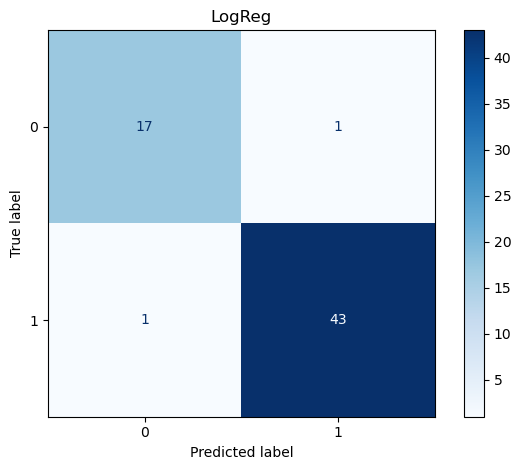

In [80]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(
    solver="liblinear",
    max_iter=20000,
    class_weight="balanced",
    random_state=42,
)
logreg = eval_and_log("LogReg", logreg, X_train, y_train, X_val, y_val)

DecisionTree

 {'accuracy': 0.9355, 'precision': 0.9762, 'recall': 0.9318, 'f1': 0.9535}


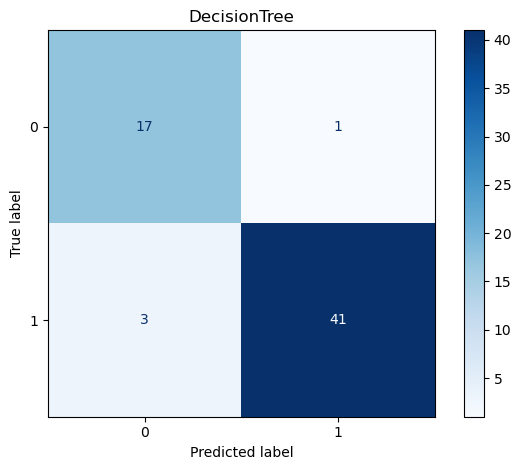

In [81]:
# обучим и оценим дерево решений с балансировкой классов (class_weight='balanced') и фиксированным random_state для воспроизводимости результатов
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(class_weight="balanced", random_state=42)
dt = eval_and_log("DecisionTree", dt, X_train, y_train, X_val, y_val)

RandomForest {'accuracy': 0.9355, 'precision': 0.9167, 'recall': 1.0, 'f1': 0.9565}


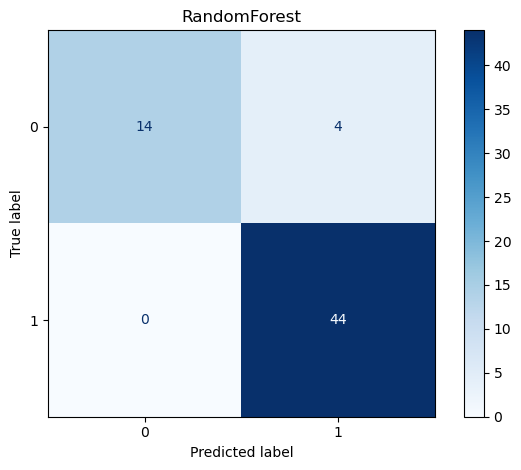

In [82]:
# обучим и оценим случайный лес с балансировкой классов (class_weight='balanced'), увеличенным числом деревьев (n_estimators=600) для лучшей производительности и фиксированным random_state для воспроизводимости результатов. Также используем n_jobs=-1 для ускорения обучения на всех доступных ядрах процессора.
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=600, class_weight="balanced", random_state=42, n_jobs=-1)
rf = eval_and_log("RandomForest", rf, X_train, y_train, X_val, y_val)

KNN {'accuracy': 0.6774, 'precision': 0.7727, 'recall': 0.7727, 'f1': 0.7727}


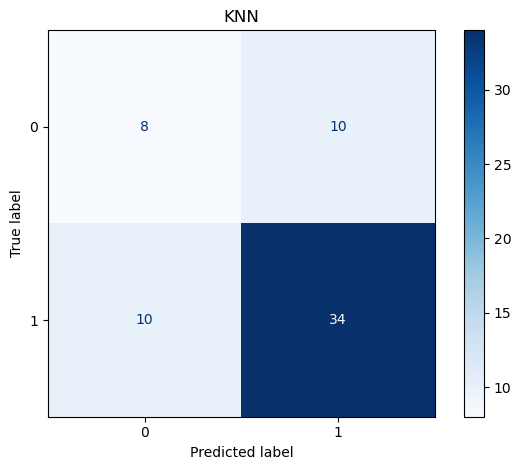

In [83]:
# обучим и оценим градиентный бустинг с балансировкой классов (scale_pos_weight) и фиксированным random_state для воспроизводимости результатов. Увеличим число итераций (n_estimators=600) для лучшей производительности.
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=7, weights="distance")
knn = eval_and_log("KNN", knn, X_train, y_train, X_val, y_val)

In [84]:
# обучим и оценим градиентный бустинг с балансировкой классов (scale_pos_weight) и фиксированным random_state для воспроизводимости результатов. Увеличим число итераций (n_estimators=600) для лучшей производительности.
summary = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
display(summary)

,model,accuracy,precision,recall,f1
0,LogReg,0.967742,0.977273,0.977273,0.977273
1,RandomForest,0.935484,0.916667,1.000000,0.956522
2,DecisionTree,0.935484,0.976190,0.931818,0.953488
3,KNN,0.677419,0.772727,0.772727,0.772727


Мы обучили и сравнили четыре алгоритма (Logistic Regression, Decision Tree, Random Forest, KNN) на валидационной выборке по метрикам accuracy, precision, recall и F1.

Лучший результат показала логистическая регрессия: accuracy ≈ 0.968, F1 ≈ 0.977 — модель наиболее стабильно и точно классифицирует объекты.
Случайный лес и дерево решений тоже дали высокие результаты (F1 ≈ 0.957 и 0.953 соответственно), но уступили логистической регрессии.
KNN показал заметно худшее качество (accuracy ≈ 0.677, F1 ≈ 0.773), поэтому для нашей задачи он подходит хуже.

Таким образом, в качестве итоговой модели целесообразно выбрать Logistic Regression, так как она дала наилучшее качество по основным метрикам и показала наиболее сбалансированную классификацию классов.

In [85]:
# Берём лучшую модель
best_model = logreg

# Обучаем на всём train (точка с запятой подавляет вывод объекта)
best_model.fit(X, y);
print("Готово: модель обучена на всём train")

Готово: модель обучена на всём train


In [86]:
test_pred = best_model.predict(test).astype(int)

submission = pd.DataFrame({
    "index": range(len(test_pred)),
    "Onshore/Offshore": test_pred
})
submission.to_csv("/Users/darasaporeva/Desktop/submission_logreg.csv", index=False)

display(submission.head())
print("Saved: submission_logreg.csv")

,index,Onshore/Offshore
0,0,1
1,1,0
2,2,1
3,3,0
4,4,1


Saved: submission_logreg.csv
